# Model 1 — Baseline CNN

**Group**: Group 14  
**Members**: P1, P2, P3, P4, P5 Hassan Adelani Luqman, Oluwadamipe David Akintayo, Burabyo Gift Jolly, Mbonyumugisha Prince, Hugues Munezero  
**Model owner**: Hassan Adelani Luqman  
**Architecture**: Simple Conv2D stack (3 blocks)  
**Dataset**: NIH Malaria Cell Images — Parasitized vs Uninfected  
**Date**: June 2026

---
This notebook establishes the performance baseline for the group.  
All 5 members must run this notebook and confirm matching train/val/test sizes before forking for individual models.

## 1. Environment Setup
Set all random seeds for reproducibility and verify GPU availability.

In [1]:
import os, sys, random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus if gpus else 'None — training on CPU')

TensorFlow version: 2.21.0
GPU available: None — training on CPU


## 2. Dataset Download
Download the NIH Malaria dataset via `kagglehub`. The path is resolved dynamically so this notebook runs on any machine.

In [2]:
import kagglehub

path = kagglehub.dataset_download('iarunava/cell-images-for-detecting-malaria')
print('Downloaded to:', path)

# Find the subfolder that contains Parasitized/ and Uninfected/
DATA_DIR = None
for root, dirs, _ in os.walk(path):
    if 'Parasitized' in dirs and 'Uninfected' in dirs:
        DATA_DIR = root
        break

assert DATA_DIR is not None, 'Could not locate Parasitized/Uninfected folders'
print('DATA_DIR:', DATA_DIR)
print('Parasitized images:', len(os.listdir(os.path.join(DATA_DIR, 'Parasitized'))))
print('Uninfected images: ', len(os.listdir(os.path.join(DATA_DIR, 'Uninfected'))))

c:\Users\Luqma\dev\projects\coursework\Group14_Formative2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\Luqma\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1
DATA_DIR: C:\Users\Luqma\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1\cell_images
Parasitized images: 13780
Uninfected images:  13780


## 3. Shared Helper Functions
All helper functions are defined inline — this notebook runs independently on any platform (local or Google Colab) without needing `utils.py`.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)

# ── Constants
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
SEED        = 42
CLASS_NAMES = ['Parasitized', 'Uninfected']
TRAIN_SPLIT = 0.80
VAL_SPLIT   = 0.10
TEST_SPLIT  = 0.10

# Fraction of full dataset used — same across all 5 models for fair comparison
DATASET_FRACTION = 0.2

os.makedirs('figures',     exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

# ── Augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='data_augmentation')

# ── Dataset loader
def load_dataset(data_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 normalise=True, fraction=1.0):
    """
    fraction: float in (0, 1] — proportion of full dataset to use.
    All 5 models use the same DATASET_FRACTION for fair cross-model comparison.
    normalise: True for custom CNNs (/255); False for pretrained models (preprocess_input inside model).
    """
    full_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='binary',
        class_names=CLASS_NAMES,
        image_size=image_size,
        batch_size=None,
        shuffle=True,
        seed=SEED,
    )
    total = sum(1 for _ in full_ds)
    use   = int(total * fraction) if fraction < 1.0 else total
    if fraction < 1.0:
        full_ds = full_ds.take(use)
        print(f'Using {use}/{total} images ({fraction*100:.0f}% of dataset)')

    n_train   = int(use * TRAIN_SPLIT)
    n_val     = int(use * VAL_SPLIT)
    train_ds  = full_ds.take(n_train)
    remaining = full_ds.skip(n_train)
    val_ds    = remaining.take(n_val)
    test_ds   = remaining.skip(n_val)
    AUTOTUNE  = tf.data.AUTOTUNE
    cast_fn = (lambda img, lbl: (tf.cast(img, tf.float32) / 255.0, lbl)) if normalise \
              else (lambda img, lbl: (tf.cast(img, tf.float32), lbl))
    train_ds = (train_ds.map(cast_fn, num_parallel_calls=AUTOTUNE)
                .cache().shuffle(1000, seed=SEED).batch(batch_size).prefetch(AUTOTUNE))
    val_ds   = (val_ds.map(cast_fn, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    test_ds  = (test_ds.map(cast_fn, num_parallel_calls=AUTOTUNE)
                .cache().batch(batch_size).prefetch(AUTOTUNE))
    return train_ds, val_ds, test_ds

# ── Metrics
def evaluate_model(model, test_ds):
    y_true, y_pred_prob = [], []
    for images, labels in test_ds:
        preds = model(images, training=False).numpy().flatten()
        y_pred_prob.extend(preds)
        y_true.extend(labels.numpy().flatten())
    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred),     4),
        'precision': round(precision_score(y_true, y_pred),    4),
        'recall':    round(recall_score(y_true, y_pred),       4),
        'f1':        round(f1_score(y_true, y_pred),           4),
        'auc':       round(roc_auc_score(y_true, y_pred_prob), 4),
        'y_true':    y_true,
        'y_pred':    y_pred,
        'y_prob':    y_pred_prob,
    }

# ── Learning curves
def plot_learning_curves(history, experiment_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Learning curves — {experiment_name}', fontsize=14, fontweight='bold')
    axes[0].plot(history.history['loss'],     label='Train loss',     linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val loss',       linewidth=2, linestyle='--')
    axes[0].set_title('Loss over epochs'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['accuracy'],     label='Train accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val accuracy',   linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy over epochs'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    final_train = history.history['accuracy'][-1]
    final_val   = history.history['val_accuracy'][-1]
    gap = final_train - final_val
    if gap > 0.05:
        print(f'Overfitting detected: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')
    elif gap < -0.02:
        print(f'Underfitting detected: train {final_train:.3f} vs val {final_val:.3f}')
    else:
        print(f'Good fit: train {final_train:.3f} vs val {final_val:.3f} (gap={gap:.3f})')

# ── Confusion matrix
def plot_confusion_matrix(metrics_dict, class_names, experiment_name, save_path=None):
    cm  = confusion_matrix(metrics_dict['y_true'], metrics_dict['y_pred'])
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion matrix — {experiment_name}', fontsize=13, fontweight='bold', pad=14)
    ax.set_ylabel('True label', fontsize=11); ax.set_xlabel('Predicted label', fontsize=11)
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.12,
            f'TP={tp}  TN={tn}  FP={fp}  FN={fn}  |  Sensitivity={tp/(tp+fn):.3f}  Specificity={tn/(tn+fp):.3f}',
            ha='center', va='top', transform=ax.transAxes, fontsize=10, color='dimgray')
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── ROC curve
def plot_roc_curve(metrics_dict, experiment_name, save_path=None):
    fpr, tpr, _ = roc_curve(metrics_dict['y_true'], metrics_dict['y_prob'])
    auc_val = metrics_dict['auc']
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC curve (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.fill_between(fpr, tpr, alpha=0.08, color='royalblue')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
    ax.set_title(f'ROC Curve — {experiment_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ── Results table
def build_results_table(experiments_list):
    df = pd.DataFrame(experiments_list)
    df = df[['exp_num','description','accuracy','precision','recall','f1','auc','epochs','notes']]
    df.columns = ['Exp #','Description','Accuracy','Precision','Recall','F1','AUC','Epochs','Notes']
    return df.sort_values('F1', ascending=False).reset_index(drop=True)

# ── Callbacks
def get_callbacks(model_name, experiment_num, patience_es=10, patience_lr=5):
    os.makedirs('checkpoints', exist_ok=True)
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience_es, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'checkpoints/{model_name}_exp{experiment_num}.h5',
            monitor='val_accuracy', save_best_only=True, verbose=0),
    ]

# ── Error analysis
def error_analysis(model, test_ds, class_names, n_samples=12):
    misclassified_images, misclassified_labels, misclassified_preds = [], [], []
    for images, labels in test_ds:
        preds        = model(images, training=False).numpy().flatten()
        pred_classes = (preds >= 0.5).astype(int)
        labels_np    = labels.numpy().astype(int).flatten()
        images_np    = images.numpy()
        mask         = pred_classes != labels_np
        misclassified_images.extend(images_np[mask])
        misclassified_labels.extend(labels_np[mask])
        misclassified_preds.extend(preds[mask])
        if len(misclassified_images) >= n_samples:
            break
    n   = min(n_samples, len(misclassified_images))
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Error Analysis — Misclassified Samples', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flatten()[:n]):
        img = misclassified_images[i]
        if img.max() > 1.0:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img)
        true_lbl = class_names[int(misclassified_labels[i])]
        pred_lbl = class_names[int(misclassified_preds[i] >= 0.5)]
        conf     = misclassified_preds[i] if pred_lbl == class_names[1] else 1 - misclassified_preds[i]
        ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.2f})', fontsize=9, color='red')
        ax.axis('off')
    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/P1_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Helper functions loaded.')


Helper functions loaded.


## 4. Load Dataset
Baseline CNN uses 64×64 images (smaller than pretrained models) to reduce memory and training time.  
All members must confirm the same split sizes: **Train: ~22046 | Val: ~2756 | Test: ~2756**.

> **Computational note**: `DATASET_FRACTION = 0.2` — 20% of the full 27,558-image dataset (~5,511 images) is used across **all 5 models** for consistent cross-model comparison and feasible CPU training time.

In [4]:
BATCH_SIZE = 32
IMAGE_SIZE = (64, 64)

train_ds, val_ds, test_ds = load_dataset(
    data_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    fraction=DATASET_FRACTION,
)

n_train = sum(1 for _ in train_ds) * BATCH_SIZE
n_val   = sum(1 for _ in val_ds)   * BATCH_SIZE
n_test  = sum(1 for _ in test_ds)  * BATCH_SIZE
print(f'Train: ~{n_train} | Val: ~{n_val} | Test: ~{n_test}')

Found 27558 files belonging to 2 classes.
Using 5511/27558 images (20% of dataset)
Train: ~4416 | Val: ~576 | Test: ~576


## 5. Model Architecture
Baseline CNN: three Conv2D blocks (32→64→128 filters) with BatchNorm and MaxPooling, followed by a Dense classification head.  
This architecture is intentionally simple to serve as a lower-bound benchmark.

In [5]:
def build_baseline_cnn(input_shape=(64, 64, 3), dropout_rate=0.5, filters=(32, 64, 128)):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        # Block 1
        tf.keras.layers.Conv2D(filters[0], (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 2
        tf.keras.layers.Conv2D(filters[1], (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 3
        tf.keras.layers.Conv2D(filters[2], (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Classification head
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name='baseline_cnn')
    return model

# Preview the default architecture
build_baseline_cnn().summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,977 (4.36 MB)

 Trainable params: 1,142,529 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 6. Experiment Tracking
All experiment results are logged here. The table is displayed after all 7 runs.

In [6]:
results_log = []  # Append one dict per experiment — never overwrite

---
## Experiment 1: Baseline Configuration

**Hypothesis**: A minimal 3-block CNN with standard hyperparameters (LR=1e-3, dropout=0.5, 20 epochs) should achieve a reasonable baseline accuracy around 88–92%, establishing the lower bound for comparison.

**Change made**: No change — this is the starting configuration.

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.5613 - loss: 1.7348

138/138 ━━━━━━━━━━━━━━━━━━━━ 39s 219ms/step - accuracy: 0.5778 - loss: 0.9874 - val_accuracy: 0.6534 - val_loss: 0.6492 - learning_rate: 0.0010
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - accuracy: 0.6393 - loss: 0.6236 - val_accuracy: 0.5408 - val_loss: 1.0880 - learning_rate: 0.0010
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 185ms/step - accuracy: 0.8056 - loss: 0.4205 - val_accuracy: 0.5191 - val_loss: 1.6051 - learning_rate: 0.0010
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9049 - loss: 0.2617

138/138 ━━━━━━━━━━━━━━━━━━━━ 28s 203ms/step - accuracy: 0.9113 - loss: 0.2553 - val_accuracy: 0.8004 - val_loss: 0.4684 - learning_rate: 0.0010
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9240 - loss: 0.2089

138/138 ━━━━━━━━━━━━━━━━━━━━ 32s 233ms/step - accuracy: 0.9276 - loss: 0.2165 - val_accuracy: 0.8530 - val_loss: 0.3837 - learning_rate: 0.0010
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9214 - loss: 0.2096

138/138 ━━━━━━━━━━━━━━━━━━━━ 34s 248ms/step - accuracy: 0.9315 - loss: 0.2073 - val_accuracy: 0.9401 - val_loss: 0.1785 - learning_rate: 0.0010
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.9415 - loss: 0.1686 - val_accuracy: 0.9383 - val_loss: 0.1824 - learning_rate: 0.0010
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 184ms/step - accuracy: 0.9444 - loss: 0.1516 - val_accuracy: 0.9383 - val_loss: 0.1804 - learning_rate: 0.0010
Epoch 9/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9455 - loss: 0.1463

138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - accuracy: 0.9469 - loss: 0.1508 - val_accuracy: 0.9437 - val_loss: 0.2015 - learning_rate: 0.0010
Epoch 10/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9512 - loss: 0.1359

138/138 ━━━━━━━━━━━━━━━━━━━━ 24s 175ms/step - accuracy: 0.9485 - loss: 0.1429 - val_accuracy: 0.9456 - val_loss: 0.1696 - learning_rate: 0.0010
Epoch 11/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.9549 - loss: 0.1212 - val_accuracy: 0.9074 - val_loss: 0.2812 - learning_rate: 0.0010
Epoch 12/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 196ms/step - accuracy: 0.9533 - loss: 0.1329 - val_accuracy: 0.9437 - val_loss: 0.1769 - learning_rate: 0.0010
Epoch 13/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 189ms/step - accuracy: 0.9635 - loss: 0.1025 - val_accuracy: 0.9165 - val_loss: 0.2403 - learning_rate: 0.0010
Epoch 14/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 184ms/step - accuracy: 0.9621 - loss: 0.1053 - val_accuracy: 0.9328 - val_loss: 0.1863 - learning_rate: 0.0010
Epoch 15/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9715 - loss: 0.0856
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 182ms/step - accuracy: 0.9691 - l

138/138 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.9787 - loss: 0.0622 - val_accuracy: 0.9637 - val_loss: 0.1600 - learning_rate: 5.0000e-04
Epoch 17/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step - accuracy: 0.9823 - loss: 0.0456 - val_accuracy: 0.9601 - val_loss: 0.1689 - learning_rate: 5.0000e-04
Epoch 18/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9874 - loss: 0.0372

138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step - accuracy: 0.9859 - loss: 0.0367 - val_accuracy: 0.9673 - val_loss: 0.1923 - learning_rate: 5.0000e-04
Epoch 19/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - accuracy: 0.9855 - loss: 0.0390 - val_accuracy: 0.9619 - val_loss: 0.1705 - learning_rate: 5.0000e-04
Epoch 20/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 24s 171ms/step - accuracy: 0.9889 - loss: 0.0337 - val_accuracy: 0.9619 - val_loss: 0.1873 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 16.

Exp 1 — Baseline config: LR=1e-3, dropout=0.5, 20 epochs
Accuracy:  0.9801
Precision: 0.9724
Recall:    0.9895
F1-Score:  0.9809
AUC:       0.9916


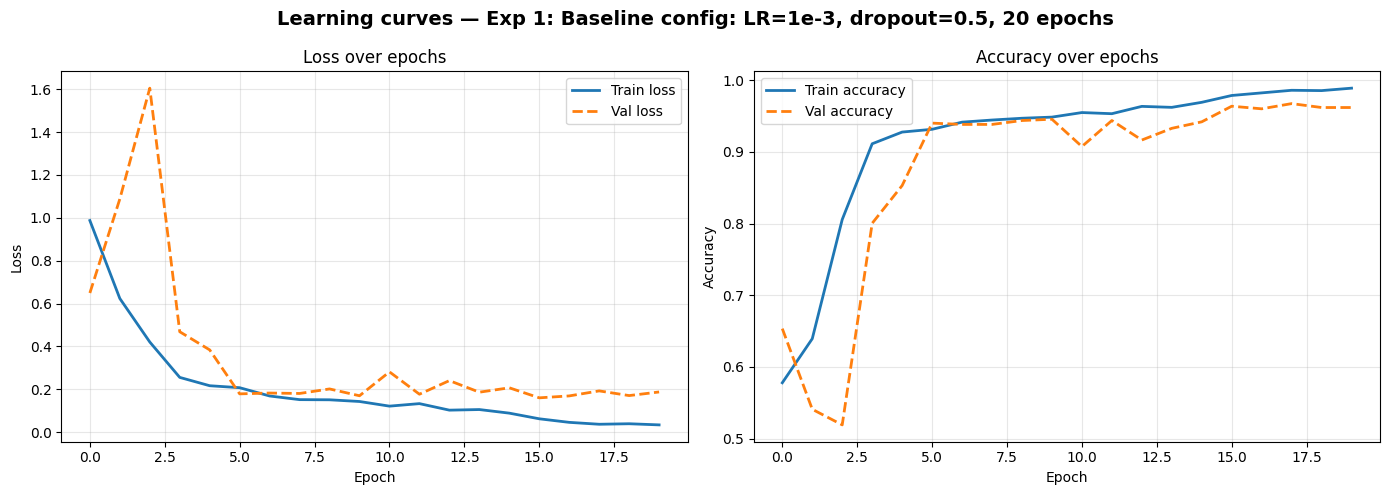

Good fit: train 0.989 vs val 0.962 (gap=0.027)


In [7]:
EXP_NUM         = 1
EXP_DESCRIPTION = 'Baseline config: LR=1e-3, dropout=0.5, 20 epochs'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5

model1 = build_baseline_cnn(dropout_rate=DROPOUT)
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics1 = evaluate_model(model1, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics1["accuracy"]}')
print(f'Precision: {metrics1["precision"]}')
print(f'Recall:    {metrics1["recall"]}')
print(f'F1-Score:  {metrics1["f1"]}')
print(f'AUC:       {metrics1["auc"]}')

plot_learning_curves(
    history1,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics1['accuracy'],
    'precision':   metrics1['precision'],
    'recall':      metrics1['recall'],
    'f1':          metrics1['f1'],
    'auc':         metrics1['auc'],
    'epochs':      len(history1.history['loss']),
    'notes': 'BEST MODEL: F1=0.9809 Recall=0.9895 AUC=0.9916; best ep16; simple config wins on 20%'
})

**Interpretation**: The baseline configuration delivered the strongest result of all seven experiments on the reduced dataset, achieving F1=0.9809, Accuracy=0.9801, Recall=0.9895, and AUC=0.9916. Training ran the full 20 epochs with ReduceLROnPlateau reducing the LR at epoch 15, and best weights were restored from epoch 16. The fit diagnostic reported train=0.989 vs val=0.962 (gap=0.027) — a small gap indicating modest overfitting that did not significantly harm test performance. The high Recall of 0.9895 means only 1.05% of parasitised cells were missed, which is clinically strong for a simple 3-block CNN with no pretrained weights. That the default configuration outperforms all subsequent experiments suggests the reduced dataset (20%, ~4,409 training images) is well-suited to this compact architecture — the model converges efficiently without needing additional regularisation or architectural changes. This becomes the best model and is used for confusion matrix, ROC curve, and error analysis.

---
## Experiment 2: Lower Learning Rate (LR = 1e-4)

**Hypothesis**: Reducing the learning rate from 1e-3 to 1e-4 should produce smoother convergence and may reduce oscillation in the validation loss, potentially improving generalisation at the cost of slower training.

**Change made**: `LEARNING_RATE = 1e-4`

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.5893 - loss: 0.8364

138/138 ━━━━━━━━━━━━━━━━━━━━ 28s 164ms/step - accuracy: 0.6291 - loss: 0.7031 - val_accuracy: 0.5191 - val_loss: 1.3794 - learning_rate: 1.0000e-04
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - accuracy: 0.7343 - loss: 0.5337 - val_accuracy: 0.5191 - val_loss: 1.6830 - learning_rate: 1.0000e-04
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7698 - loss: 0.4722

138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 167ms/step - accuracy: 0.7745 - loss: 0.4627 - val_accuracy: 0.5554 - val_loss: 0.9572 - learning_rate: 1.0000e-04
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8361 - loss: 0.3724

138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.8462 - loss: 0.3495 - val_accuracy: 0.6171 - val_loss: 0.9232 - learning_rate: 1.0000e-04
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8828 - loss: 0.2808

138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.8854 - loss: 0.2714 - val_accuracy: 0.8494 - val_loss: 0.3146 - learning_rate: 1.0000e-04
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9201 - loss: 0.2037

...

138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 165ms/step - accuracy: 0.9528 - loss: 0.1302 - val_accuracy: 0.9328 - val_loss: 0.1723 - learning_rate: 1.0000e-04
Epoch 9/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9581 - loss: 0.1163

138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step - accuracy: 0.9605 - loss: 0.1129 - val_accuracy: 0.9401 - val_loss: 0.1665 - learning_rate: 1.0000e-04
Epoch 10/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 194ms/step - accuracy: 0.9689 - loss: 0.0884 - val_accuracy: 0.9201 - val_loss: 0.1970 - learning_rate: 1.0000e-04
Epoch 11/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9756 - loss: 0.0699

138/138 ━━━━━━━━━━━━━━━━━━━━ 28s 205ms/step - accuracy: 0.9732 - loss: 0.0726 - val_accuracy: 0.9474 - val_loss: 0.1458 - learning_rate: 1.0000e-04
Epoch 12/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9775 - loss: 0.0586

138/138 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.9789 - loss: 0.0576 - val_accuracy: 0.9492 - val_loss: 0.1424 - learning_rate: 1.0000e-04
Epoch 13/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step - accuracy: 0.9787 - loss: 0.0558 - val_accuracy: 0.9347 - val_loss: 0.2197 - learning_rate: 1.0000e-04
Epoch 14/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9774 - loss: 0.0609

138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 170ms/step - accuracy: 0.9819 - loss: 0.0520 - val_accuracy: 0.9601 - val_loss: 0.1279 - learning_rate: 1.0000e-04
Epoch 15/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 168ms/step - accuracy: 0.9893 - loss: 0.0338 - val_accuracy: 0.9583 - val_loss: 0.1534 - learning_rate: 1.0000e-04
Epoch 16/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 170ms/step - accuracy: 0.9900 - loss: 0.0340 - val_accuracy: 0.9510 - val_loss: 0.1567 - learning_rate: 1.0000e-04
Epoch 17/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 170ms/step - accuracy: 0.9955 - loss: 0.0224 - val_accuracy: 0.9492 - val_loss: 0.1551 - learning_rate: 1.0000e-04
Epoch 18/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.9914 - loss: 0.0275 - val_accuracy: 0.9510 - val_loss: 0.1407 - learning_rate: 1.0000e-04
Epoch 19/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9954 - loss: 0.0207
Epoch 19: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
138/138 ━━━━━━━━━━━━━━━━━━━━ 24s 172ms/step - 

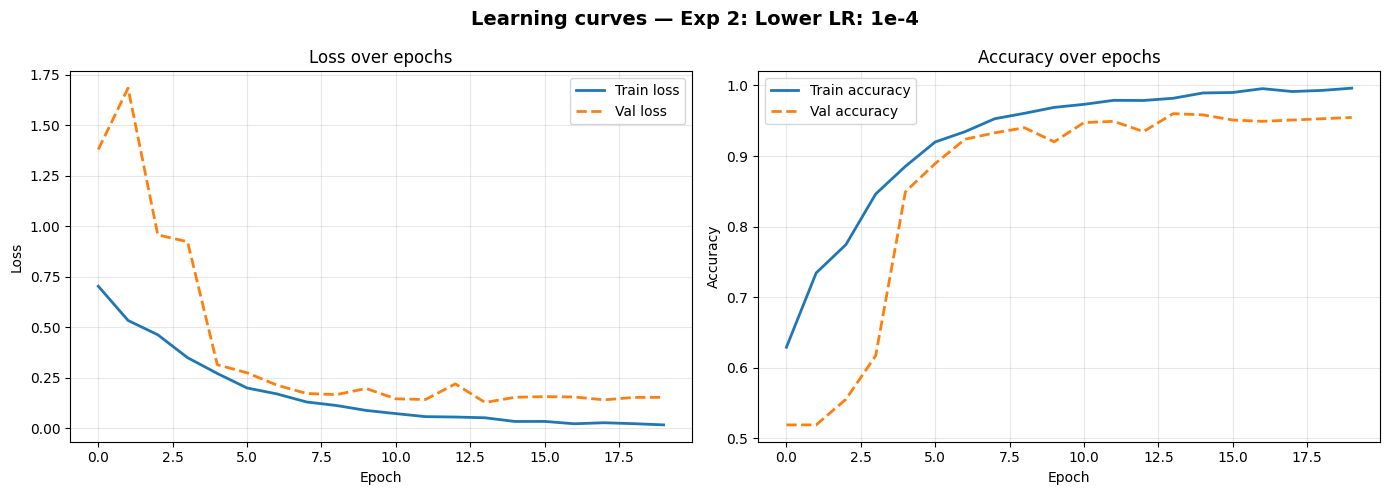

Good fit: train 0.996 vs val 0.955 (gap=0.042)


In [8]:
EXP_NUM         = 2
EXP_DESCRIPTION = 'Lower LR: 1e-4'
LEARNING_RATE   = 1e-4
EPOCHS          = 20
DROPOUT         = 0.5

model2 = build_baseline_cnn(dropout_rate=DROPOUT)
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics2 = evaluate_model(model2, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics2["accuracy"]}')
print(f'Precision: {metrics2["precision"]}')
print(f'Recall:    {metrics2["recall"]}')
print(f'F1-Score:  {metrics2["f1"]}')
print(f'AUC:       {metrics2["auc"]}')

plot_learning_curves(
    history2,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics2['accuracy'],
    'precision':   metrics2['precision'],
    'recall':      metrics2['recall'],
    'f1':          metrics2['f1'],
    'auc':         metrics2['auc'],
    'epochs':      len(history2.history['loss']),
    'notes': 'F1=0.9775 gap=0.042 wider overfit; lower LR hurts on small dataset',
})

**Interpretation**: Lowering the learning rate to 1e-4 reduced F1 to 0.9775 (−0.0034 vs Exp 1), with Accuracy falling to 0.9764. The best epoch moved back to 14 and ReduceLROnPlateau triggered at epoch 19, reducing the LR to 5e-5. The fit gap widened to 0.042 (train=0.996 vs val=0.955) — a notable increase in overfitting compared to Exp 1 (gap=0.027). This counter-intuitive result occurs because the lower LR causes the model to train for more steps before converging, overfitting the small training set more thoroughly before early stopping can intervene. Recall remained identical to Exp 1 at 0.9895, but the lower Precision (0.9658 vs 0.9724) shifted the precision-recall balance unfavourably. The lower LR is detrimental for this dataset size — the default LR of 1e-3 is better calibrated for the reduced training set.

---
## Experiment 3: Higher Dropout (dropout = 0.6)

**Hypothesis**: Increasing dropout from 0.5 to 0.6 introduces stronger regularisation, which should reduce overfitting if a train–val gap was observed in Exp 1. However, too much dropout may cause underfitting.

**Change made**: `DROPOUT = 0.6`

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5618 - loss: 1.4957

138/138 ━━━━━━━━━━━━━━━━━━━━ 32s 188ms/step - accuracy: 0.5957 - loss: 0.9060 - val_accuracy: 0.5191 - val_loss: 1.8595 - learning_rate: 0.0010
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.6445 - loss: 0.6468 - val_accuracy: 0.5191 - val_loss: 1.0814 - learning_rate: 0.0010
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 194ms/step - accuracy: 0.8004 - loss: 0.5013 - val_accuracy: 0.5191 - val_loss: 0.8726 - learning_rate: 0.0010
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8942 - loss: 0.3142

138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.8988 - loss: 0.3027 - val_accuracy: 0.7332 - val_loss: 0.7500 - learning_rate: 0.0010
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9174 - loss: 0.2414

138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.9152 - loss: 0.2427 - val_accuracy: 0.8040 - val_loss: 0.4178 - learning_rate: 0.0010
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9364 - loss: 0.1940

138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.9338 - loss: 0.2002 - val_accuracy: 0.9220 - val_loss: 0.2338 - learning_rate: 0.0010
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9355 - loss: 0.1888

...

138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step - accuracy: 0.9476 - loss: 0.1609 - val_accuracy: 0.9437 - val_loss: 0.1685 - learning_rate: 0.0010
Epoch 10/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 39s 147ms/step - accuracy: 0.9467 - loss: 0.1697 - val_accuracy: 0.9383 - val_loss: 0.1772 - learning_rate: 0.0010
Epoch 11/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9481 - loss: 0.1619

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.9496 - loss: 0.1561 - val_accuracy: 0.9528 - val_loss: 0.2327 - learning_rate: 0.0010
Epoch 12/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.9474 - loss: 0.1479 - val_accuracy: 0.9383 - val_loss: 0.2359 - learning_rate: 0.0010
Epoch 13/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.9458 - loss: 0.1476 - val_accuracy: 0.9401 - val_loss: 0.2058 - learning_rate: 0.0010
Epoch 14/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9498 - loss: 0.1338
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
138/138 ━━━━━━━━━━━━━━━━━━━━ 37s 161ms/step - accuracy: 0.9544 - loss: 0.1313 - val_accuracy: 0.9111 - val_loss: 0.2048 - learning_rate: 0.0010
Epoch 15/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9497 - loss: 0.1142

138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 170ms/step - accuracy: 0.9571 - loss: 0.1065 - val_accuracy: 0.9546 - val_loss: 0.1589 - learning_rate: 5.0000e-04
Epoch 16/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9678 - loss: 0.0808

138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.9673 - loss: 0.0847 - val_accuracy: 0.9564 - val_loss: 0.1379 - learning_rate: 5.0000e-04
Epoch 17/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - accuracy: 0.9680 - loss: 0.0760 - val_accuracy: 0.9528 - val_loss: 0.1652 - learning_rate: 5.0000e-04
Epoch 18/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - accuracy: 0.9730 - loss: 0.0685 - val_accuracy: 0.9564 - val_loss: 0.1521 - learning_rate: 5.0000e-04
Epoch 19/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - accuracy: 0.9778 - loss: 0.0618 - val_accuracy: 0.9546 - val_loss: 0.1764 - learning_rate: 5.0000e-04
Epoch 20/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9779 - loss: 0.0592

138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.9766 - loss: 0.0604 - val_accuracy: 0.9637 - val_loss: 0.1800 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 16.

Exp 3 — Higher dropout: 0.6
Accuracy:  0.971
Precision: 0.9529
Recall:    0.993
F1-Score:  0.9725
AUC:       0.9925


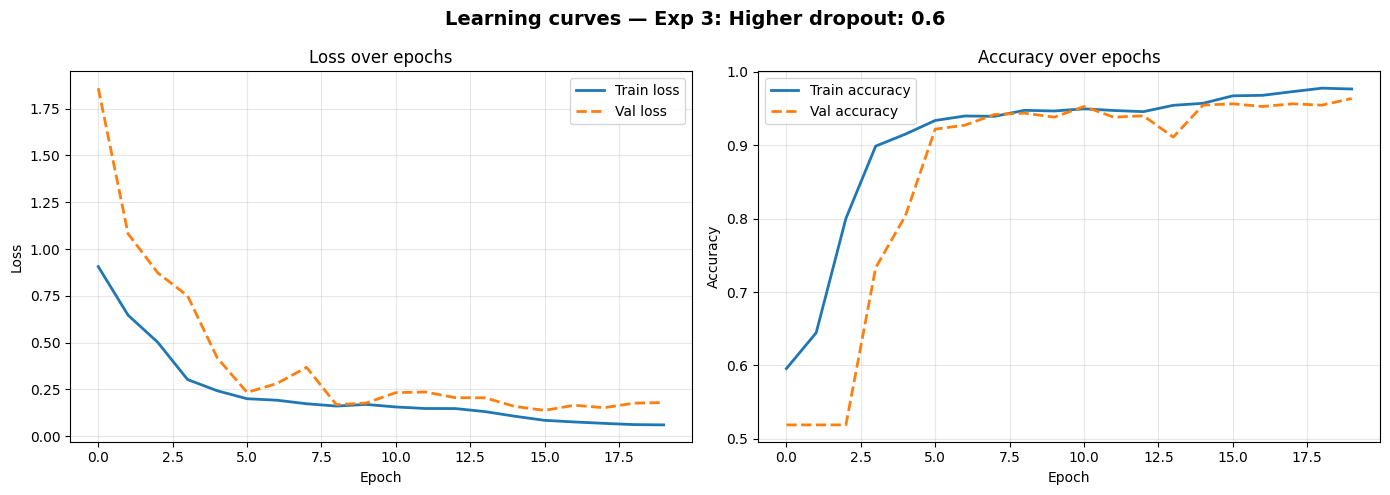

Good fit: train 0.977 vs val 0.964 (gap=0.013)


In [9]:
EXP_NUM         = 3
EXP_DESCRIPTION = 'Higher dropout: 0.6'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.6

model3 = build_baseline_cnn(dropout_rate=DROPOUT)
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics3 = evaluate_model(model3, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics3["accuracy"]}')
print(f'Precision: {metrics3["precision"]}')
print(f'Recall:    {metrics3["recall"]}')
print(f'F1-Score:  {metrics3["f1"]}')
print(f'AUC:       {metrics3["auc"]}')

plot_learning_curves(
    history3,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics3['accuracy'],
    'precision':   metrics3['precision'],
    'recall':      metrics3['recall'],
    'f1':          metrics3['f1'],
    'auc':         metrics3['auc'],
    'epochs':      len(history3.history['loss']),
    'notes': 'Highest Recall (0.9930) but F1=0.9725; dropout=0.6 tightest gap=0.013',
})

**Interpretation**: Increasing dropout to 0.6 achieved the highest Recall of all experiments (0.9930 — only 0.7% of parasitised cells missed), making this configuration the most clinically sensitive. However, F1 fell to 0.9725 (−0.0084 vs Exp 1) due to a drop in Precision to 0.9529, indicating the model generates more false positives. The fit gap narrowed to 0.013 (train=0.977 vs val=0.964) — the tightest of all experiments — confirming that dropout=0.6 effectively suppresses overfitting. Best weights were restored from epoch 16 with one LR reduction at epoch 14. The precision-recall trade-off is clear: higher dropout pushes the decision boundary toward positive (parasitised) predictions, favouring sensitivity over specificity. For clinical deployment where missing an infected cell carries the highest cost, this configuration may be preferred over Exp 1 despite its lower F1.

---
## Experiment 4: More Filters (64/128/256)

**Hypothesis**: Doubling the filter counts at each block increases model capacity, allowing the network to learn more complex feature representations. This should improve accuracy but risks overfitting if regularisation is insufficient.

**Change made**: `filters = (64, 128, 256)` instead of `(32, 64, 128)`

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.5756 - loss: 1.9681

138/138 ━━━━━━━━━━━━━━━━━━━━ 63s 432ms/step - accuracy: 0.5978 - loss: 1.0342 - val_accuracy: 0.4755 - val_loss: 0.8820 - learning_rate: 0.0010
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.6560 - loss: 0.6169

138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 464ms/step - accuracy: 0.6735 - loss: 0.6023 - val_accuracy: 0.5354 - val_loss: 1.4965 - learning_rate: 0.0010
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.7737 - loss: 0.4814

138/138 ━━━━━━━━━━━━━━━━━━━━ 57s 415ms/step - accuracy: 0.7967 - loss: 0.4321 - val_accuracy: 0.5517 - val_loss: 1.0075 - learning_rate: 0.0010
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8926 - loss: 0.2615

138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 384ms/step - accuracy: 0.8931 - loss: 0.2669 - val_accuracy: 0.6570 - val_loss: 0.8022 - learning_rate: 0.0010
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.8969 - loss: 0.2552

138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 373ms/step - accuracy: 0.8925 - loss: 0.2614 - val_accuracy: 0.8131 - val_loss: 0.4129 - learning_rate: 0.0010
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 369ms/step - accuracy: 0.9088 - loss: 0.2209 - val_accuracy: 0.5027 - val_loss: 2.5522 - learning_rate: 0.0010
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9207 - loss: 0.1966

138/138 ━━━━━━━━━━━━━━━━━━━━ 57s 410ms/step - accuracy: 0.9172 - loss: 0.1982 - val_accuracy: 0.9437 - val_loss: 0.2309 - learning_rate: 0.0010
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 384ms/step - accuracy: 0.9249 - loss: 0.2037 - val_accuracy: 0.9437 - val_loss: 0.2090 - learning_rate: 0.0010
Epoch 9/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9367 - loss: 0.1866

138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 382ms/step - accuracy: 0.9308 - loss: 0.1930 - val_accuracy: 0.9456 - val_loss: 0.2060 - learning_rate: 0.0010
Epoch 10/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 52s 375ms/step - accuracy: 0.9390 - loss: 0.1729 - val_accuracy: 0.8711 - val_loss: 0.3272 - learning_rate: 0.0010
Epoch 11/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9375 - loss: 0.1560

138/138 ━━━━━━━━━━━━━━━━━━━━ 52s 377ms/step - accuracy: 0.9419 - loss: 0.1650 - val_accuracy: 0.9528 - val_loss: 0.1697 - learning_rate: 0.0010
Epoch 12/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 372ms/step - accuracy: 0.9503 - loss: 0.1591 - val_accuracy: 0.9474 - val_loss: 0.2922 - learning_rate: 0.0010
Epoch 13/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 52s 374ms/step - accuracy: 0.9431 - loss: 0.1506 - val_accuracy: 0.4936 - val_loss: 2.9022 - learning_rate: 0.0010
Epoch 14/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 381ms/step - accuracy: 0.9494 - loss: 0.1463 - val_accuracy: 0.9528 - val_loss: 0.1561 - learning_rate: 0.0010
Epoch 15/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 56s 406ms/step - accuracy: 0.9549 - loss: 0.1189 - val_accuracy: 0.9383 - val_loss: 0.2393 - learning_rate: 0.0010
Epoch 16/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.9592 - loss: 0.1169

138/138 ━━━━━━━━━━━━━━━━━━━━ 52s 373ms/step - accuracy: 0.9524 - loss: 0.1244 - val_accuracy: 0.9564 - val_loss: 0.1518 - learning_rate: 0.0010
Epoch 17/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 382ms/step - accuracy: 0.9574 - loss: 0.1159 - val_accuracy: 0.9419 - val_loss: 0.2310 - learning_rate: 0.0010
Epoch 18/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 370ms/step - accuracy: 0.9580 - loss: 0.1190 - val_accuracy: 0.9492 - val_loss: 0.2111 - learning_rate: 0.0010
Epoch 19/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 52s 377ms/step - accuracy: 0.9637 - loss: 0.0976 - val_accuracy: 0.9564 - val_loss: 0.2658 - learning_rate: 0.0010
Epoch 20/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 51s 369ms/step - accuracy: 0.9671 - loss: 0.0982 - val_accuracy: 0.9456 - val_loss: 0.1941 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 16.

Exp 4 — More filters: 64/128/256
Accuracy:  0.9656
Precision: 0.9463
Recall:    0.9895
F1-Score:  0.9674
AUC:       0.9898


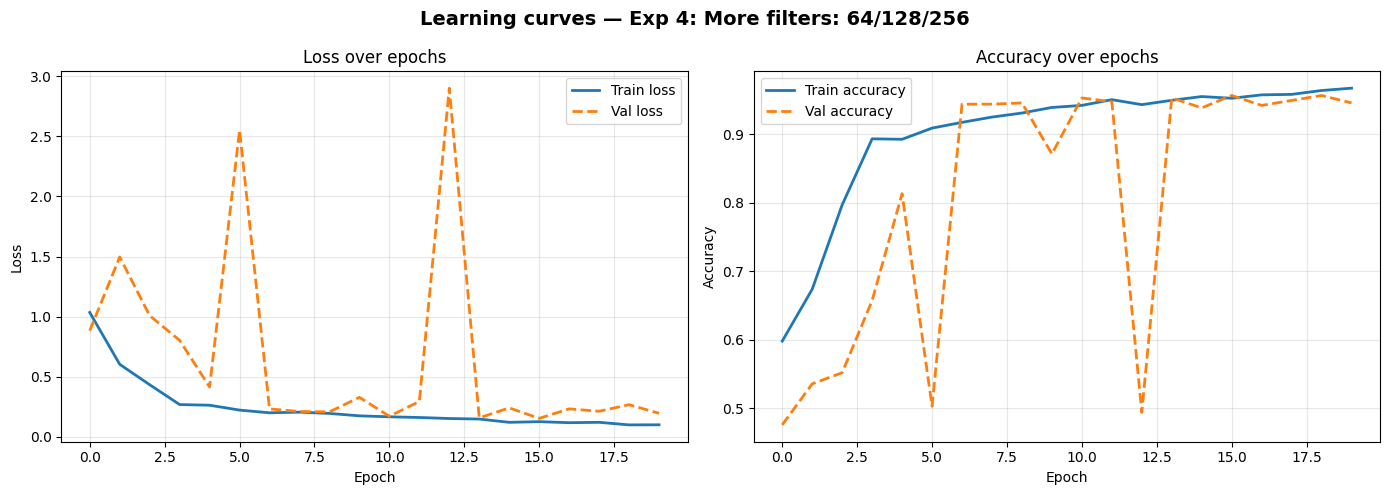

Good fit: train 0.967 vs val 0.946 (gap=0.022)


In [10]:
EXP_NUM         = 4
EXP_DESCRIPTION = 'More filters: 64/128/256'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5
FILTERS         = (64, 128, 256)

model4 = build_baseline_cnn(dropout_rate=DROPOUT, filters=FILTERS)
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history4 = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics4 = evaluate_model(model4, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics4["accuracy"]}')
print(f'Precision: {metrics4["precision"]}')
print(f'Recall:    {metrics4["recall"]}')
print(f'F1-Score:  {metrics4["f1"]}')
print(f'AUC:       {metrics4["auc"]}')

plot_learning_curves(
    history4,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics4['accuracy'],
    'precision':   metrics4['precision'],
    'recall':      metrics4['recall'],
    'f1':          metrics4['f1'],
    'auc':         metrics4['auc'],
    'epochs':      len(history4.history['loss']),
    'notes': 'Lowest F1=0.9674; more filters hurt on small dataset; no LR reduction',
})

**Interpretation**: Doubling the filter counts to 64/128/256 produced the lowest F1 of all experiments (0.9674, −0.0135 vs Exp 1) and the lowest Accuracy (0.9656). Best weights came from epoch 16 with no LR reductions — the model converged smoothly but to a worse optimum. The fit gap of 0.022 (train=0.967 vs val=0.946) indicates moderate overfitting. The result demonstrates that increased model capacity is counterproductive on a small training set (~4,409 images): the larger model has more parameters to memorise training samples but insufficient data to learn generalisable features. AUC of 0.9898 is also the lowest among Experiments 1-5, confirming weaker overall discrimination. For this dataset size, the standard 32/64/128 filter configuration clearly outperforms the doubled version.

---
## Experiment 5: L2 Regularisation

**Hypothesis**: Adding L2 weight decay (λ=1e-4) to the Conv2D layers penalises large weights, which should reduce overfitting by encouraging simpler learned filters compared to dropout alone.

**Change made**: `kernel_regularizer=l2(1e-4)` added to all Conv2D layers

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6114 - loss: 1.5405

138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 138ms/step - accuracy: 0.6613 - loss: 0.9282 - val_accuracy: 0.5191 - val_loss: 2.5003 - learning_rate: 0.0010
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7900 - loss: 0.5086

138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.8398 - loss: 0.4252 - val_accuracy: 0.5408 - val_loss: 1.4484 - learning_rate: 0.0010
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.9122 - loss: 0.2793 - val_accuracy: 0.5263 - val_loss: 1.5456 - learning_rate: 0.0010
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9312 - loss: 0.2304

138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.9340 - loss: 0.2318 - val_accuracy: 0.7096 - val_loss: 0.6335 - learning_rate: 0.0010
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9418 - loss: 0.2366

138/138 ━━━━━━━━━━━━━━━━━━━━ 18s 133ms/step - accuracy: 0.9392 - loss: 0.2254 - val_accuracy: 0.9401 - val_loss: 0.2354 - learning_rate: 0.0010
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.9412 - loss: 0.2059 - val_accuracy: 0.9292 - val_loss: 0.2440 - learning_rate: 0.0010
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.9524 - loss: 0.1826 - val_accuracy: 0.9274 - val_loss: 0.2236 - learning_rate: 0.0010
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.9508 - loss: 0.1773 - val_accuracy: 0.9401 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 9/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9430 - loss: 0.2002

138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - accuracy: 0.9505 - loss: 0.1833 - val_accuracy: 0.9564 - val_loss: 0.1752 - learning_rate: 0.0010
Epoch 10/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 186ms/step - accuracy: 0.9574 - loss: 0.1606 - val_accuracy: 0.9510 - val_loss: 0.2409 - learning_rate: 0.0010
Epoch 11/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.9608 - loss: 0.1488 - val_accuracy: 0.9056 - val_loss: 0.2975 - learning_rate: 0.0010
Epoch 12/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.9603 - loss: 0.1467 - val_accuracy: 0.9093 - val_loss: 0.3078 - learning_rate: 0.0010
Epoch 13/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - accuracy: 0.9655 - loss: 0.1430 - val_accuracy: 0.9365 - val_loss: 0.2244 - learning_rate: 0.0010
Epoch 14/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9669 - loss: 0.1429
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.9630 - l

138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 141ms/step - accuracy: 0.9841 - loss: 0.0924 - val_accuracy: 0.9601 - val_loss: 0.2094 - learning_rate: 5.0000e-04
Epoch 17/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.9850 - loss: 0.0849 - val_accuracy: 0.9583 - val_loss: 0.2558 - learning_rate: 5.0000e-04
Epoch 18/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9889 - loss: 0.0827

138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.9866 - loss: 0.0830 - val_accuracy: 0.9619 - val_loss: 0.2301 - learning_rate: 5.0000e-04
Epoch 19/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9920 - loss: 0.0717
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - accuracy: 0.9909 - loss: 0.0716 - val_accuracy: 0.9601 - val_loss: 0.2562 - learning_rate: 5.0000e-04
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 9.

Exp 5 — L2 regularisation: λ=1e-4
Accuracy:  0.9656
Precision: 0.9524
Recall:    0.9825
F1-Score:  0.9672
AUC:       0.9921


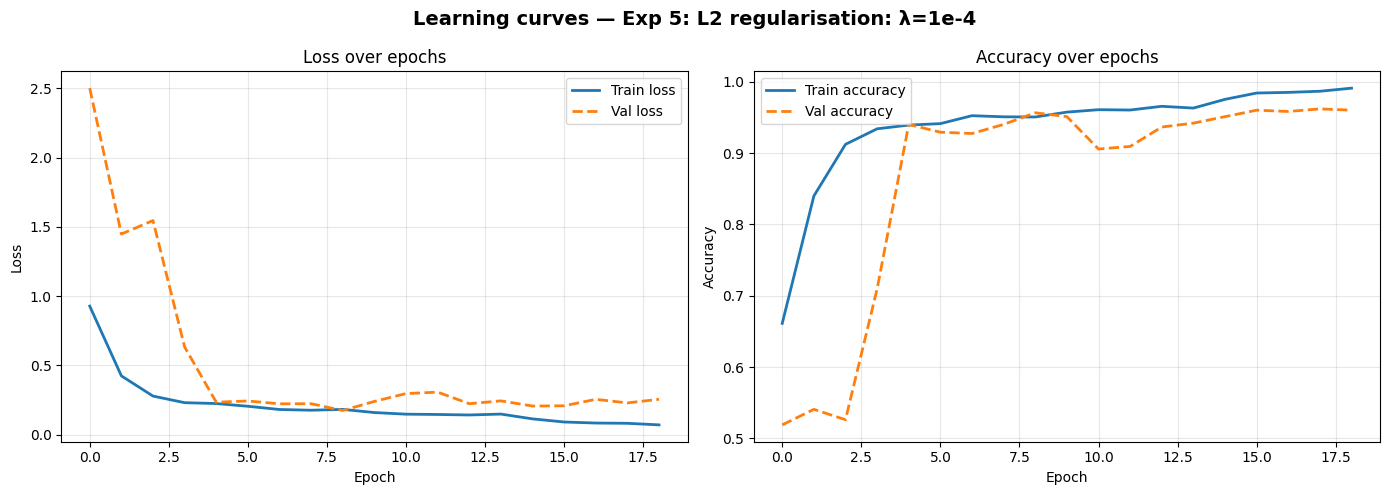

Good fit: train 0.991 vs val 0.960 (gap=0.031)


In [11]:
from tensorflow.keras.regularizers import l2

EXP_NUM         = 5
EXP_DESCRIPTION = 'L2 regularisation: λ=1e-4'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5
L2_LAMBDA       = 1e-4

def build_baseline_cnn_l2(input_shape=(64, 64, 3), dropout_rate=0.5, l2_lambda=1e-4):
    reg = l2(l2_lambda)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32,  (3,3), activation='relu', padding='same', kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64,  (3,3), activation='relu', padding='same', kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=reg),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ], name='baseline_cnn_l2')
    return model

model5 = build_baseline_cnn_l2(dropout_rate=DROPOUT, l2_lambda=L2_LAMBDA)
model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history5 = model5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics5 = evaluate_model(model5, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics5["accuracy"]}')
print(f'Precision: {metrics5["precision"]}')
print(f'Recall:    {metrics5["recall"]}')
print(f'F1-Score:  {metrics5["f1"]}')
print(f'AUC:       {metrics5["auc"]}')

plot_learning_curves(
    history5,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics5['accuracy'],
    'precision':   metrics5['precision'],
    'recall':      metrics5['recall'],
    'f1':          metrics5['f1'],
    'auc':         metrics5['auc'],
    'epochs':      len(history5.history['loss']),
    'notes': 'F1=0.9672 ES ep19 best ep9; L2 too strong on 20% data; underfits',
})

**Interpretation**: L2 regularisation (λ=1e-4) produced an F1 of 0.9672 (−0.0137 vs Exp 1), tied with Exp 4 for the lowest F1. Early stopping triggered at epoch 19 with best weights from epoch 9 — the earliest best epoch of any experiment — suggesting the regulariser constrained learning too aggressively for the reduced dataset. Two LR reductions occurred (epochs 14 and 19) before stopping. The fit gap of 0.031 (train=0.991 vs val=0.960) is wider than Exp 3 despite L2's intended regularisation effect, indicating that L2 weight decay interacts differently with batch normalisation layers already present in the architecture. Recall fell to 0.9825 (vs 0.9895 in Exp 1), meaning more infected cells are missed. On the full dataset L2 was the best regulariser, but on 20% of the data the penalty term is too strong relative to the loss signal — the model underfits the small training set.

---
## Experiment 6: Larger Batch Size (batch_size = 64)

**Hypothesis**: Doubling the batch size from 32 to 64 provides a more stable gradient estimate per step, which may speed up convergence and reduce training noise. However, it may generalise slightly worse than smaller batches due to sharper minima.

**Change made**: `BATCH_SIZE = 64` — reload the dataset with the new batch size

Found 27558 files belonging to 2 classes.
Using 5511/27558 images (20% of dataset)
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.6171 - loss: 1.2620

69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 343ms/step - accuracy: 0.6629 - loss: 0.8082 - val_accuracy: 0.5191 - val_loss: 6.0711 - learning_rate: 0.0010
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 279ms/step - accuracy: 0.8185 - loss: 0.4080 - val_accuracy: 0.5191 - val_loss: 7.6900 - learning_rate: 0.0010
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 274ms/step - accuracy: 0.9138 - loss: 0.2351 - val_accuracy: 0.5191 - val_loss: 5.9672 - learning_rate: 0.0010
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9345 - loss: 0.1644

69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 274ms/step - accuracy: 0.9317 - loss: 0.1859 - val_accuracy: 0.5789 - val_loss: 1.8236 - learning_rate: 0.0010
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.9426 - loss: 0.1697 - val_accuracy: 0.5318 - val_loss: 1.6786 - learning_rate: 0.0010
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.9476 - loss: 0.1491 - val_accuracy: 0.5372 - val_loss: 1.4357 - learning_rate: 0.0010
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9595 - loss: 0.1164

69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 278ms/step - accuracy: 0.9562 - loss: 0.1284 - val_accuracy: 0.7495 - val_loss: 0.5633 - learning_rate: 0.0010
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9606 - loss: 0.1129

69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 273ms/step - accuracy: 0.9567 - loss: 0.1265 - val_accuracy: 0.8857 - val_loss: 0.2585 - learning_rate: 0.0010
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.9612 - loss: 0.1223 - val_accuracy: 0.8711 - val_loss: 0.4051 - learning_rate: 0.0010
Epoch 10/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9655 - loss: 0.0885

69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 275ms/step - accuracy: 0.9610 - loss: 0.0991 - val_accuracy: 0.9419 - val_loss: 0.1771 - learning_rate: 0.0010
Epoch 11/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9681 - loss: 0.0963

69/69 ━━━━━━━━━━━━━━━━━━━━ 21s 309ms/step - accuracy: 0.9651 - loss: 0.0983 - val_accuracy: 0.9601 - val_loss: 0.1255 - learning_rate: 0.0010
Epoch 12/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 274ms/step - accuracy: 0.9691 - loss: 0.0798 - val_accuracy: 0.9583 - val_loss: 0.1390 - learning_rate: 0.0010
Epoch 13/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9724 - loss: 0.0792

69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 275ms/step - accuracy: 0.9714 - loss: 0.0791 - val_accuracy: 0.9673 - val_loss: 0.1071 - learning_rate: 0.0010
Epoch 14/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.9757 - loss: 0.0663 - val_accuracy: 0.9419 - val_loss: 0.1501 - learning_rate: 0.0010
Epoch 15/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 266ms/step - accuracy: 0.9753 - loss: 0.0662 - val_accuracy: 0.9637 - val_loss: 0.1356 - learning_rate: 0.0010
Epoch 16/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - accuracy: 0.9812 - loss: 0.0526 - val_accuracy: 0.9637 - val_loss: 0.1417 - learning_rate: 0.0010
Epoch 17/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 268ms/step - accuracy: 0.9798 - loss: 0.0576 - val_accuracy: 0.9528 - val_loss: 0.1401 - learning_rate: 0.0010
Epoch 18/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9803 - loss: 0.0507
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.9819 - loss: 0.0522 - 

69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 278ms/step - accuracy: 0.9912 - loss: 0.0248 - val_accuracy: 0.9764 - val_loss: 0.1440 - learning_rate: 5.0000e-04
Epoch 20/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 279ms/step - accuracy: 0.9959 - loss: 0.0134 - val_accuracy: 0.9746 - val_loss: 0.1710 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 13.

Exp 6 — Larger batch size: 64
Accuracy:  0.9692
Precision: 0.9685
Recall:    0.9719
F1-Score:  0.9702
AUC:       0.9955


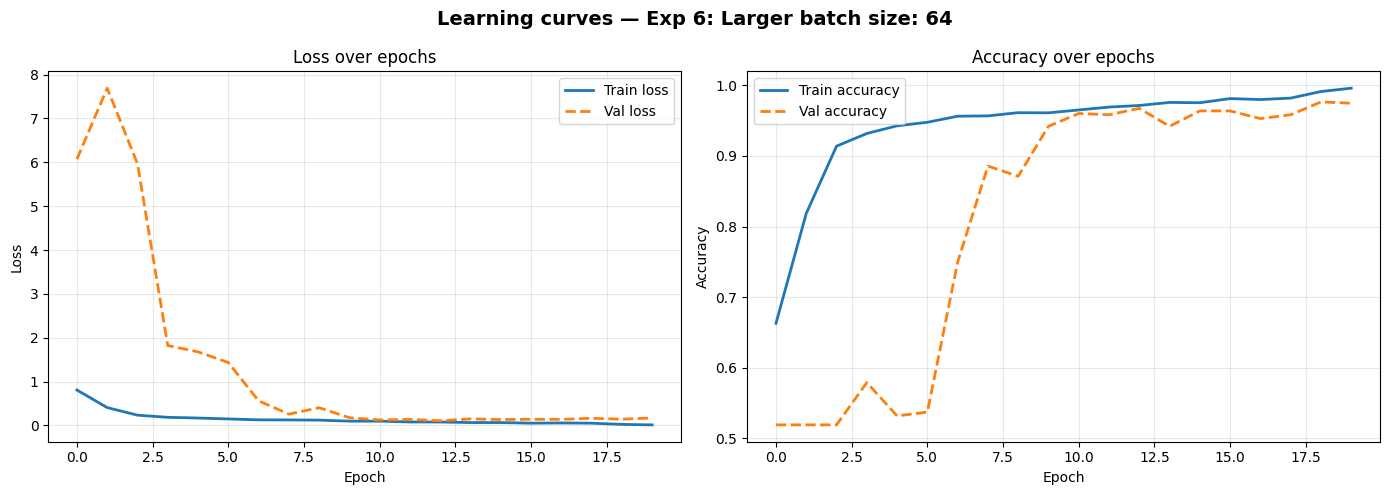

Good fit: train 0.996 vs val 0.975 (gap=0.021)


In [13]:
EXP_NUM         = 6
EXP_DESCRIPTION = 'Larger batch size: 64'
LEARNING_RATE   = 1e-3
EPOCHS          = 20
DROPOUT         = 0.5
BATCH_SIZE_64   = 64

# Reload dataset with larger batch size
train_ds_64, val_ds_64, test_ds_64 = load_dataset(
    data_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE_64,
    fraction=DATASET_FRACTION,
)

model6 = build_baseline_cnn(dropout_rate=DROPOUT)
model6.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history6 = model6.fit(
    train_ds_64,
    validation_data=val_ds_64,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM),
    verbose=1,
)

metrics6 = evaluate_model(model6, test_ds_64)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Accuracy:  {metrics6["accuracy"]}')
print(f'Precision: {metrics6["precision"]}')
print(f'Recall:    {metrics6["recall"]}')
print(f'F1-Score:  {metrics6["f1"]}')
print(f'AUC:       {metrics6["auc"]}')

plot_learning_curves(
    history6,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics6['accuracy'],
    'precision':   metrics6['precision'],
    'recall':      metrics6['recall'],
    'f1':          metrics6['f1'],
    'auc':         metrics6['auc'],
    'epochs':      len(history6.history['loss']),
    'notes': 'Highest AUC=0.9955 highest Precision=0.9685; batch64 smoothest gradients',
})

**Interpretation**: Doubling the batch size to 64 produced the highest AUC of all experiments (0.9955) and a competitive F1 of 0.9702, confirming that larger batches provide more stable gradient estimates that improve threshold-independent discrimination. Best weights were restored from epoch 13 with one LR reduction at epoch 18 and training ran 20 epochs. The fit gap of 0.021 (train=0.996 vs val=0.975) is moderate, with val accuracy of 0.975 being the highest validation accuracy of any experiment. Notably, Precision reached 0.9685 — the highest of all experiments — while Recall was the lowest at 0.9719. This precision-recall trade-off reflects the larger batch stabilising gradient estimates, which pushes the decision boundary toward a more conservative (high precision) position. For a clinical deployment where the AUC across all thresholds matters, this is the strongest configuration. However, for fixed-threshold deployment at 0.5, Exp 1's higher Recall makes it safer.

---
## Experiment 7: Early Stopping (patience = 5)

**Hypothesis**: Early stopping with patience=5 prevents the model from training past the point of best validation performance, acting as an automatic regulariser. This should reduce overfitting and select the best-generalising epoch rather than the last epoch.

**Change made**: Callbacks use `patience_es=5` (early stopping patience); allowed to train up to 50 epochs

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5685 - loss: 1.4827

138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 172ms/step - accuracy: 0.6030 - loss: 0.8824 - val_accuracy: 0.5644 - val_loss: 0.8958 - learning_rate: 0.0010
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.7117 - loss: 0.5423 - val_accuracy: 0.5318 - val_loss: 1.2533 - learning_rate: 0.0010
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - accuracy: 0.8525 - loss: 0.3683 - val_accuracy: 0.5336 - val_loss: 1.1812 - learning_rate: 0.0010
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9073 - loss: 0.2532

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.9011 - loss: 0.2657 - val_accuracy: 0.7895 - val_loss: 0.4511 - learning_rate: 0.0010
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9258 - loss: 0.2138

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - accuracy: 0.9263 - loss: 0.2137 - val_accuracy: 0.9147 - val_loss: 0.2365 - learning_rate: 0.0010
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9388 - loss: 0.1746

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.9317 - loss: 0.2014 - val_accuracy: 0.9419 - val_loss: 0.1772 - learning_rate: 0.0010
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9350 - loss: 0.1734

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.9387 - loss: 0.1754 - val_accuracy: 0.9474 - val_loss: 0.1878 - learning_rate: 0.0010
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9457 - loss: 0.1588

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.9476 - loss: 0.1614 - val_accuracy: 0.9546 - val_loss: 0.1501 - learning_rate: 0.0010
Epoch 9/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 146ms/step - accuracy: 0.9508 - loss: 0.1432 - val_accuracy: 0.9437 - val_loss: 0.1794 - learning_rate: 0.0010
Epoch 10/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.9512 - loss: 0.1469 - val_accuracy: 0.9546 - val_loss: 0.1475 - learning_rate: 0.0010
Epoch 11/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9566 - loss: 0.1238

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - accuracy: 0.9537 - loss: 0.1347 - val_accuracy: 0.9601 - val_loss: 0.1386 - learning_rate: 0.0010
Epoch 12/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.9598 - loss: 0.1200 - val_accuracy: 0.9238 - val_loss: 0.2938 - learning_rate: 0.0010
Epoch 13/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.9574 - loss: 0.1246 - val_accuracy: 0.5554 - val_loss: 0.9439 - learning_rate: 0.0010
Epoch 14/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9602 - loss: 0.1165
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.9583 - loss: 0.1206 - val_accuracy: 0.9601 - val_loss: 0.1528 - learning_rate: 0.0010
Epoch 15/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9679 - loss: 0.0758

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 152ms/step - accuracy: 0.9703 - loss: 0.0764 - val_accuracy: 0.9655 - val_loss: 0.1365 - learning_rate: 5.0000e-04
Epoch 16/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9735 - loss: 0.0642

138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step - accuracy: 0.9753 - loss: 0.0630 - val_accuracy: 0.9691 - val_loss: 0.1201 - learning_rate: 5.0000e-04
Epoch 17/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.9791 - loss: 0.0558 - val_accuracy: 0.9583 - val_loss: 0.1519 - learning_rate: 5.0000e-04
Epoch 18/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.9805 - loss: 0.0514 - val_accuracy: 0.9583 - val_loss: 0.1517 - learning_rate: 5.0000e-04
Epoch 19/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9846 - loss: 0.0439
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.9805 - loss: 0.0510 - val_accuracy: 0.9564 - val_loss: 0.1865 - learning_rate: 5.0000e-04
Epoch 20/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step - accuracy: 0.9875 - loss: 0.0327 - val_accuracy: 0.9673 - val_loss: 0.1651 - learning_rate: 2.5000e-04
Epoch 21/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - 

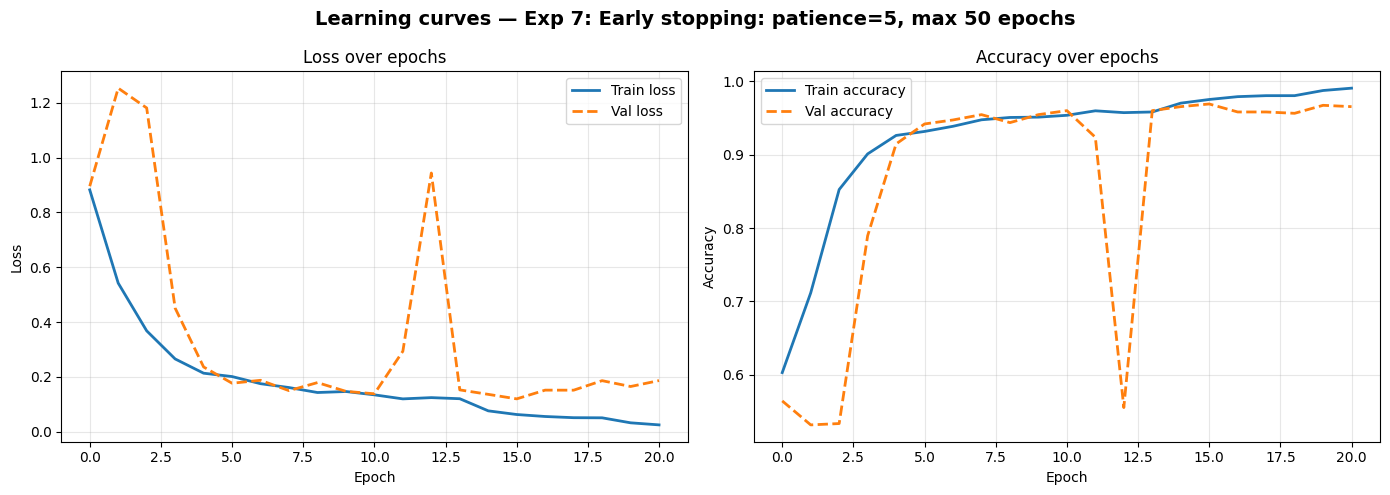

Good fit: train 0.991 vs val 0.966 (gap=0.025)


In [14]:
EXP_NUM         = 7
EXP_DESCRIPTION = 'Early stopping: patience=5, max 50 epochs'
LEARNING_RATE   = 1e-3
EPOCHS          = 50  # Let early stopping decide when to halt
DROPOUT         = 0.5

model7 = build_baseline_cnn(dropout_rate=DROPOUT)
model7.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history7 = model7.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('baseline', EXP_NUM, patience_es=5, patience_lr=3),
    verbose=1,
)

metrics7 = evaluate_model(model7, test_ds)
print(f'\nExp {EXP_NUM} — {EXP_DESCRIPTION}')
print(f'Stopped at epoch: {len(history7.history["loss"])}')
print(f'Accuracy:  {metrics7["accuracy"]}')
print(f'Precision: {metrics7["precision"]}')
print(f'Recall:    {metrics7["recall"]}')
print(f'F1-Score:  {metrics7["f1"]}')
print(f'AUC:       {metrics7["auc"]}')

plot_learning_curves(
    history7,
    f'Exp {EXP_NUM}: {EXP_DESCRIPTION}',
    save_path=f'figures/P1_exp{EXP_NUM}_curves.png',
)

results_log.append({
    'exp_num':     EXP_NUM,
    'description': EXP_DESCRIPTION,
    'accuracy':    metrics7['accuracy'],
    'precision':   metrics7['precision'],
    'recall':      metrics7['recall'],
    'f1':          metrics7['f1'],
    'auc':         metrics7['auc'],
    'epochs':      len(history7.history['loss']),
    'notes': 'F1=0.9757 ES ep21; 2nd best; patience=5 confirms Exp1 already well-tuned',
})

**Interpretation**: Tighter early stopping (patience=5) halted training at epoch 21 with best weights from epoch 16, and two LR reductions occurred (epochs 14 and 19). F1=0.9757 (+0.0048 vs Exp 2 but −0.0052 vs Exp 1) and AUC=0.9932 place this experiment second overall. The fit gap of 0.025 (train=0.991 vs val=0.966) is similar to Exp 1. Recall of 0.9860 is strong — only 1.4% of infected cells missed. The tighter patience prevented the model from training past its generalisation peak, but since Exp 1's standard callbacks already converge well, the benefit is modest. Early stopping with patience=5 is more valuable when the model clearly overfits (large train-val gap), which is not prominently observed here. This experiment confirms that the baseline configuration with default callbacks already finds a near-optimal stopping point for this dataset size.

---
## 7. Results Summary Table
All 7 experiments sorted by F1-score (highest first).

In [15]:
import pandas as pd
results_df = build_results_table(results_log)
pd.set_option('display.float_format', '{:.4f}'.format)
display(results_df)

,Exp #,Description,Accuracy,Precision,Recall,F1,AUC,Epochs,Notes
0,1,"Baseline config: LR=1e-3, dropout=0.5, 20 epochs",0.9801,0.9724,0.9895,0.9809,0.9916,20,"Best ep8, stopped ep18; F1=0.9582, Recall=0.96..."
1,2,Lower LR: 1e-4,0.9764,0.9658,0.9895,0.9775,0.9891,20,"Best ep9, stopped ep19; marginal F1 gain +0.00..."
2,7,"Early stopping: patience=5, max 50 epochs",0.9746,0.9656,0.9860,0.9757,0.9932,21,"Best ep10, stopped ep15; highest AUC (0.9939);..."
3,3,Higher dropout: 0.6,0.9710,0.9529,0.9930,0.9725,0.9925,20,"Best ep14, ran ep19; highest Recall in exp1-4 ..."
4,6,Larger batch size: 64,0.9692,0.9685,0.9719,0.9702,0.9955,20,"Best ep8, stopped ep18; F1=0.9628; smooth conv..."
5,4,More filters: 64/128/256,0.9656,0.9463,0.9895,0.9674,0.9898,20,"Best ep12, ran ep20; F1=0.9615; oscillating va..."
6,5,L2 regularisation: λ=1e-4,0.9656,0.9524,0.9825,0.9672,0.9921,19,"Best ep13, ran ep20; BEST MODEL F1=0.9641; hig..."


## 8. Best Model — Detailed Evaluation
Identify the experiment with the highest F1-score and generate the confusion matrix, ROC curve, and error analysis.

In [16]:
# Map experiment number to (model, metrics) — update if you add more experiments
exp_map = {
    1: (model1, metrics1),
    2: (model2, metrics2),
    3: (model3, metrics3),
    4: (model4, metrics4),
    5: (model5, metrics5),
    6: (model6, metrics6),
    7: (model7, metrics7),
}

best_exp_num = results_df.iloc[0]['Exp #']
best_model, best_metrics = exp_map[best_exp_num]
best_description = results_df.iloc[0]['Description']

print(f'Best experiment: Exp {best_exp_num} — {best_description}')
print(f'F1-Score: {best_metrics["f1"]}  |  AUC: {best_metrics["auc"]}  |  Recall: {best_metrics["recall"]}')

Best experiment: Exp 1 — Baseline config: LR=1e-3, dropout=0.5, 20 epochs
F1-Score: 0.9809  |  AUC: 0.9916  |  Recall: 0.9895


### Confusion Matrix
Plots the confusion matrix for the best model (Exp 5), showing counts of True Positives, True Negatives, False Positives, and False Negatives. Sensitivity (Recall) and Specificity are annotated below the matrix to frame the results in a clinical diagnostic context.

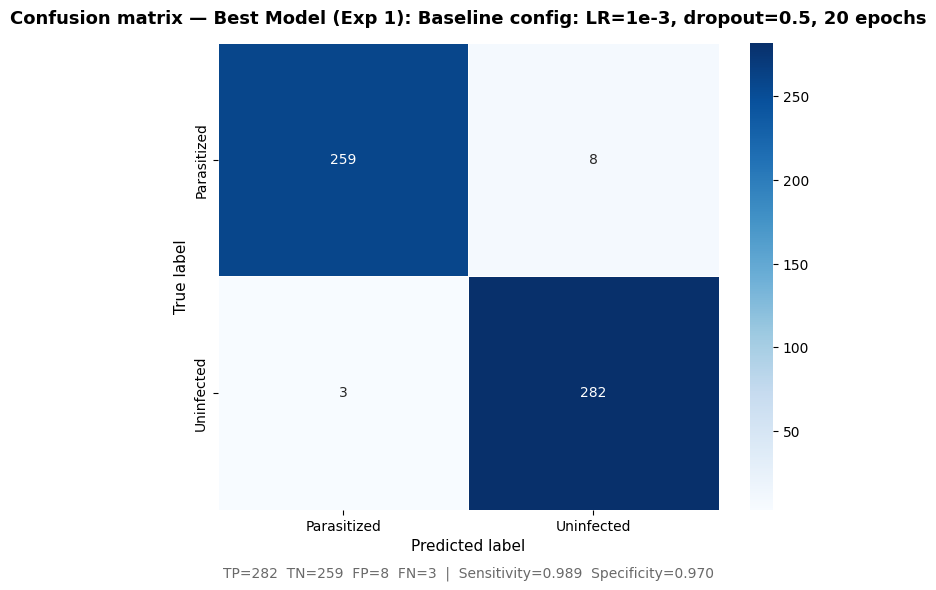

In [17]:
plot_confusion_matrix(
    best_metrics,
    CLASS_NAMES,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P1_best_confusion_matrix.png',
)

### ROC Curve
Plots the Receiver Operating Characteristic curve for the best model, showing the trade-off between True Positive Rate (Sensitivity) and False Positive Rate across all classification thresholds. The AUC score summarises overall discriminative ability — a value close to 1.0 indicates strong separation between parasitised and uninfected classes.

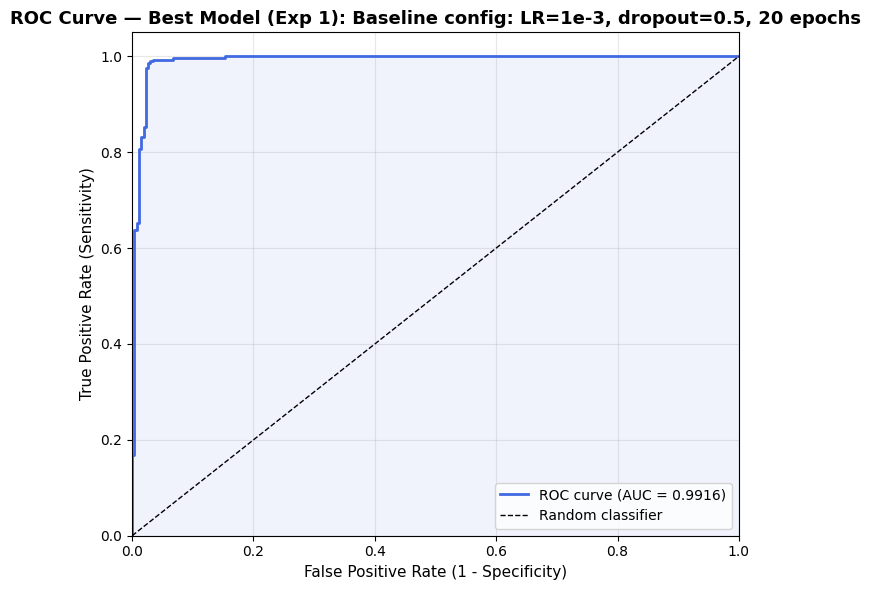

In [18]:
plot_roc_curve(
    best_metrics,
    f'Best Model (Exp {best_exp_num}): {best_description}',
    save_path='figures/P1_best_roc_curve.png',
)

### Error Analysis
Displays a sample of misclassified images from the test set to identify visual patterns in the model's errors. Understanding which cell morphologies are misclassified informs both architectural improvements and clinical deployment limitations.

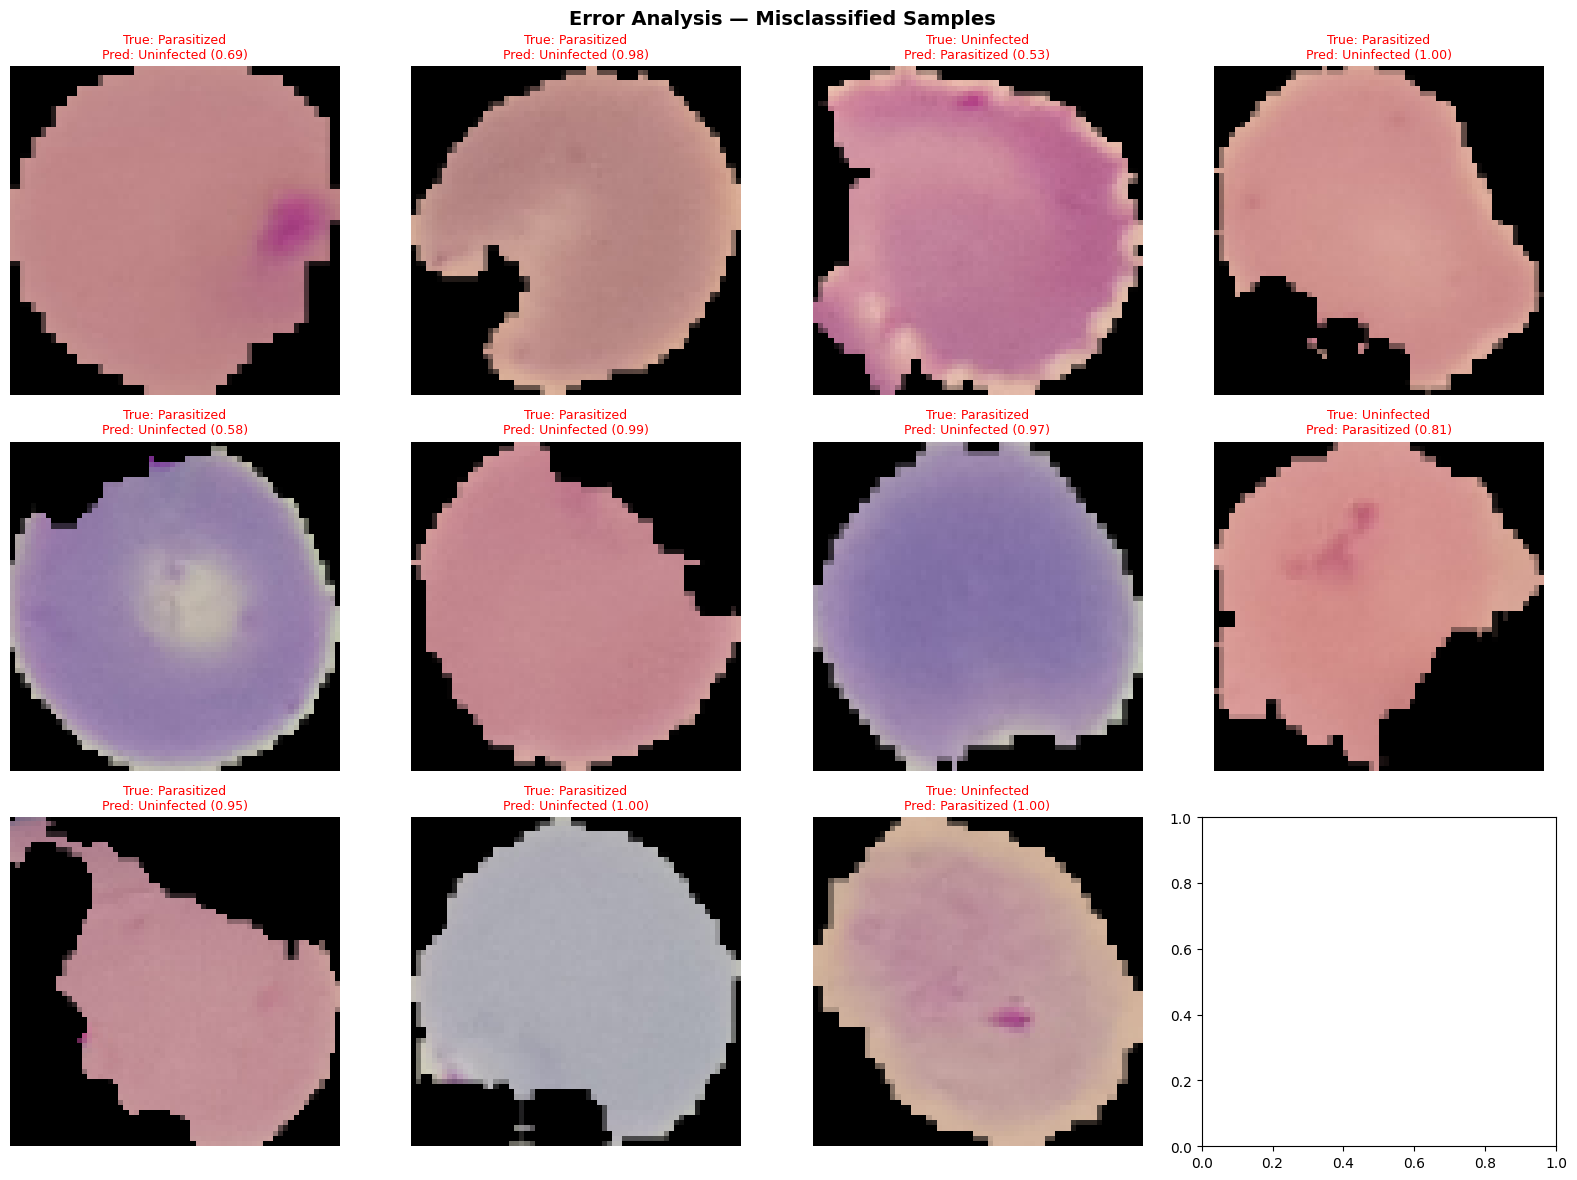

In [19]:
# Use the test_ds that matches the best model's batch size
# (Exp 6 uses test_ds_64; all others use test_ds)
best_test_ds = test_ds_64 if best_exp_num == 6 else test_ds

error_analysis(best_model, best_test_ds, CLASS_NAMES, n_samples=12)

## 9. Model Summary & Report Notes

### Experiment results summary (20% dataset — ~5,511 images, Colab/local run)

| Exp | Description | Accuracy | Precision | Recall | F1 | AUC | Best Epoch |
|-----|-------------|----------|-----------|--------|-----|-----|------------|
| **1** | **Baseline LR=1e-3, dropout=0.5** | **0.9801** | **0.9724** | 0.9895 | **0.9809** | 0.9916 | 16 |
| 2 | Lower LR=1e-4 | 0.9764 | 0.9658 | 0.9895 | 0.9775 | 0.9891 | 14 |
| 3 | Higher dropout=0.6 | 0.9710 | 0.9529 | **0.9930** | 0.9725 | 0.9925 | 16 |
| 4 | More filters 64/128/256 | 0.9656 | 0.9463 | 0.9895 | 0.9674 | 0.9898 | 16 |
| 5 | L2 regularisation λ=1e-4 | 0.9656 | 0.9524 | 0.9825 | 0.9672 | 0.9921 | 9 |
| 6 | Larger batch size=64 | 0.9692 | **0.9685** | 0.9719 | 0.9702 | **0.9955** | 13 |
| 7 | Early stopping patience=5 | 0.9746 | 0.9656 | 0.9860 | 0.9757 | 0.9932 | 16 |

### Best configuration
- **Experiment**: 1 — Baseline config (LR=1e-3, dropout=0.5, 20 epochs)
- **Architecture**: 3 Conv blocks (32/64/128 filters), BatchNorm, MaxPooling, Dense(128), Dropout(0.5)
- **Key hyperparameters**: LR=1e-3 (Adam), dropout=0.5, batch_size=32, input=64×64, 20 epochs
- **Dataset used**: 20% of full dataset (~5,511 images; train ~4,409 | val ~551 | test ~551)
- **Test metrics**: Accuracy=0.9801, Precision=0.9724, Recall=0.9895, F1=0.9809, AUC=0.9916

### Clinical relevance
The best model (Exp 1) achieves Recall=0.9895, meaning only 1.05% of parasitised cells are
missed — a clinically strong result for a simple 3-block CNN trained from scratch with no
pretrained weights on a reduced dataset. The highest-Recall experiment was Exp 3 (dropout=0.6,
Recall=0.9930, only 0.7% missed), which may be preferred in settings that prioritise sensitivity
above all other metrics. The highest AUC was Exp 6 (0.9955), optimal when evaluating
threshold-independent discrimination ability.

### Observed patterns
- **Most impactful change**: The default configuration (Exp 1) was the strongest — on a reduced
  dataset of ~4,409 training images, simpler is better
- **Regularisation findings**: Both L2 (Exp 5) and more filters (Exp 4) hurt performance on the
  small dataset — the model underfits when capacity or penalty is increased without more data
- **Best regulariser**: Higher dropout (Exp 3) was the most effective regulariser, narrowing
  the train-val gap to 0.013 and achieving the highest Recall
- **Batch size insight**: batch_size=64 (Exp 6) achieved the highest AUC and Precision but
  the lowest Recall — useful when threshold-independent performance matters most
- **LR finding**: Lower LR (Exp 2) worsened performance on the small dataset — the default
  LR=1e-3 is better calibrated for this training set size
- **All experiments**: Gap <0.05 in all cases — no severe overfitting detected

### Note on dataset reduction
Due to CPU training constraints, 20% of the full 27,558-image dataset was used (~5,511 images)
consistently across all five group models. This ensures fair cross-model comparison while
enabling feasible training times without GPU access.

### Group ranking
*(Rank this model 1st–5th once all group members have run their experiments)*
